In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(SingleCellExperiment)
    library(Seurat)
    library(scran)
    library(scater)
    library(destiny)
})
source('settings.R')

In [2]:
#io = list()
#io$atlas_sce = "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/embryo_sce.rds"
io$atlas_sce = "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds"
#outdir
io$outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/results/NN/'
dir.create(io$outdir, recursive=T, showWarning=F)

In [8]:
set.seed(123)

In [3]:
#extended.sce = readRDS(io$atlas_sce)
# meta = colData(extended.sce) %>% 
#     as.data.table() %>% 
#     .[embryo_version=='Original']
# # Subset to original atlas
# original_sce = extended.sce[,as.character(meta$cell)]
# rm(extended.sce)
original_sce = readRDS(io$atlas_sce)

In [4]:
meta = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata.txt.gz')

In [5]:
# Rename ensemble IDs to gene names in the atlas
gene_metadata <- fread(io$gene_metadata) %>% 
    .[,c("chr","ens_id","symbol")] %>%
     .[symbol!="" & ens_id%in%rownames(original_sce)] %>%
     .[!duplicated(symbol)]


In [6]:
original_sce <- original_sce[rownames(original_sce) %in% gene_metadata$ens_id,]
foo <- gene_metadata$symbol; names(foo) <- gene_metadata$ens_id
rownames(original_sce) <- foo[rownames(original_sce)]

In [7]:
TFs = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/TFs.txt", header=F)
TFs_keep = intersect(stringr::str_to_title(TFs$V1), rownames(original_sce))
sce_TFs = original_sce[TFs_keep,]

In [ ]:
sce_TFs = logNormCounts(sce_TFs, size_factors = as.numeric(sce_TFs$sizeFactor))

In [45]:
decomp <- modelGeneVar(sce_TFs)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=400) %>% rownames

In [46]:
sce_filt <- sce_TFs[hvgs,]

In [47]:
# RNA dimreduction
sce_filt <- runPCA(sce_filt, ncomponents = 30, ntop=400)


In [48]:
sce_TFs <- runUMAP(sce_TFs, dimred="PCA", n_neighbors = 30, min_dist = 0.3)

In [49]:
umap.dt <- reducedDim(sce_TFs,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_TFs)] %>%
  setnames(c("UMAP1","UMAP2","cell"))


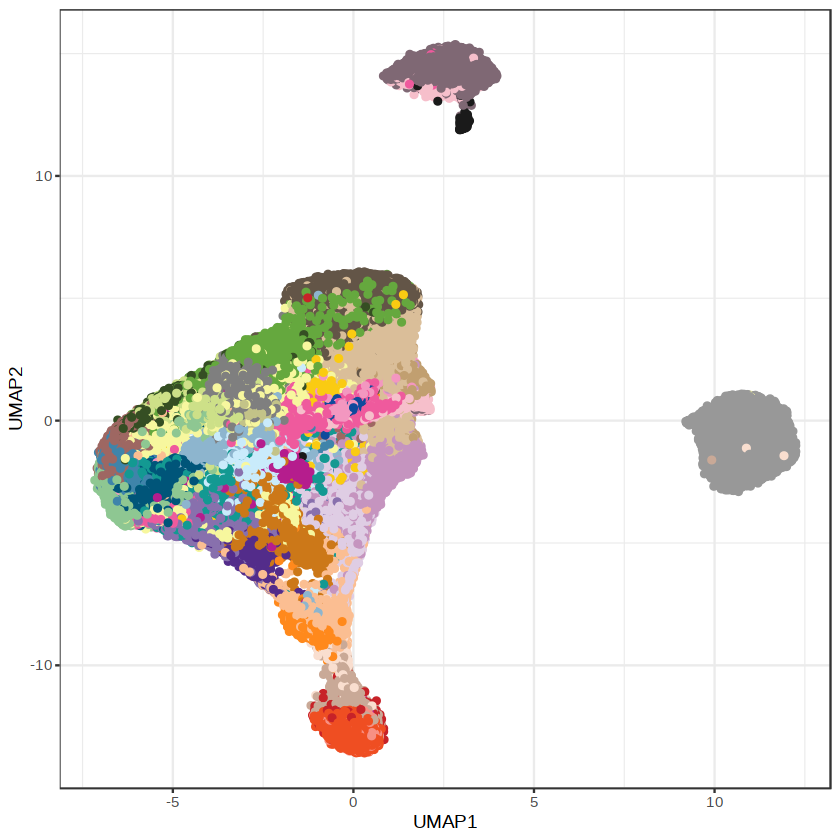

In [50]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=gsub(' ', '_', sce_TFs$celltype_PijuanSala2019))) + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void() + theme(legend.position='none')

In [53]:
# Speed shit up using parallel
library(BiocParallel)
library(parallel)
BPPARAM = MulticoreParam(detectCores()/2)

In [71]:
# Remove ExE celltypes
sce_filt <- sce_filt[,as.character(meta[!celltype_PijuanSala2019 %in% c('Visceral endoderm','ExE endoderm', 'ExE ectoderm'), cell])]

In [11]:
# RNA dimreduction
sce_filt <- runPCA(sce_filt, ncomponents = 30, ntop=400)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'runPCA': object 'sce_filt' not found


In [ ]:
a = Sys.time()

In [ ]:
sce_TFs <- runUMAP(sce_TFs, dimred="PCA", n_neighbors = 35, min_dist = 0.3, BPPARAM = BPPARAM)

In [ ]:
umap.dt <- reducedDim(sce_TFs,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_TFs)] %>%
  setnames(c("UMAP1","UMAP2","cell"))


In [ ]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=gsub(' ', '_', sce_TFs$celltype_PijuanSala2019))) + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_bw() + theme(legend.position='none')

# Expression Imputation

In [9]:
# Speed shit up using parallel
library(BiocParallel)
library(parallel)
BPPARAM = MulticoreParam(6)

In [10]:
original_sce = logNormCounts(original_sce, size_factors = as.numeric(original_sce$sizeFactor))

In [11]:
# Create PCA space based on top 3000 genes
decomp <- modelGeneVar(original_sce, meta[match(colnames(original_sce),cell)]$sample)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=3000) %>% rownames

sce_filt <- original_sce[hvgs,]

sce_filt <- runPCA(sce_filt, ncomponents = 30, ntop=3000)

Time difference of 2.579394 mins

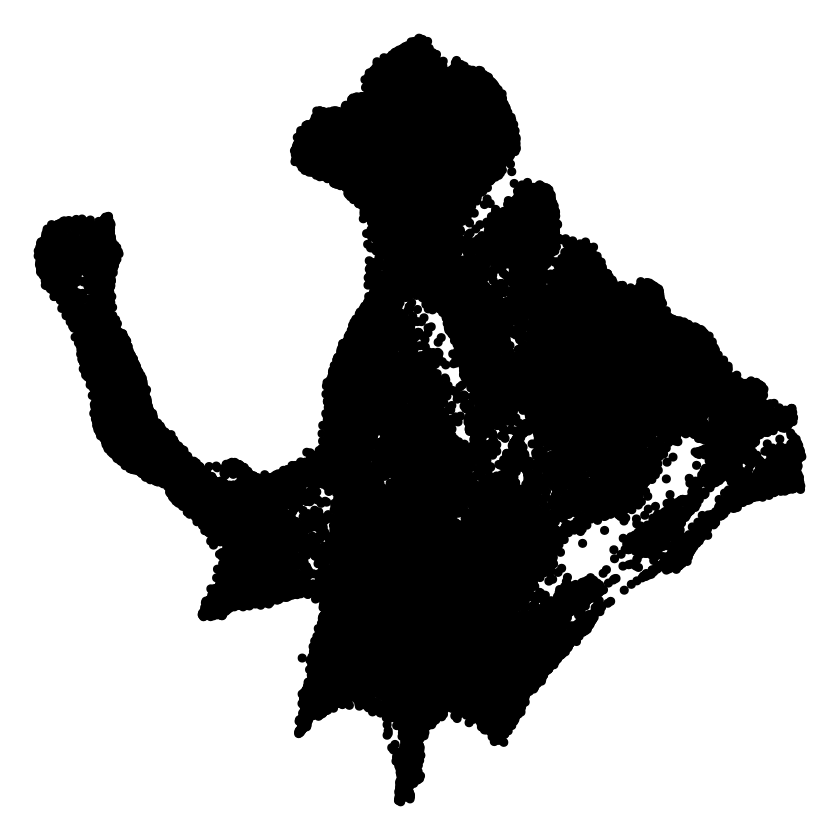

In [50]:
a = Sys.time()
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 30, min_dist = 0.3, BPPARAM = BPPARAM)
b = Sys.time()
b-a

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

ggplot(umap.dt, aes(UMAP1, UMAP2, col=meta[match(colnames(seurat), cell),celltype])) + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void() + theme(legend.position='none')

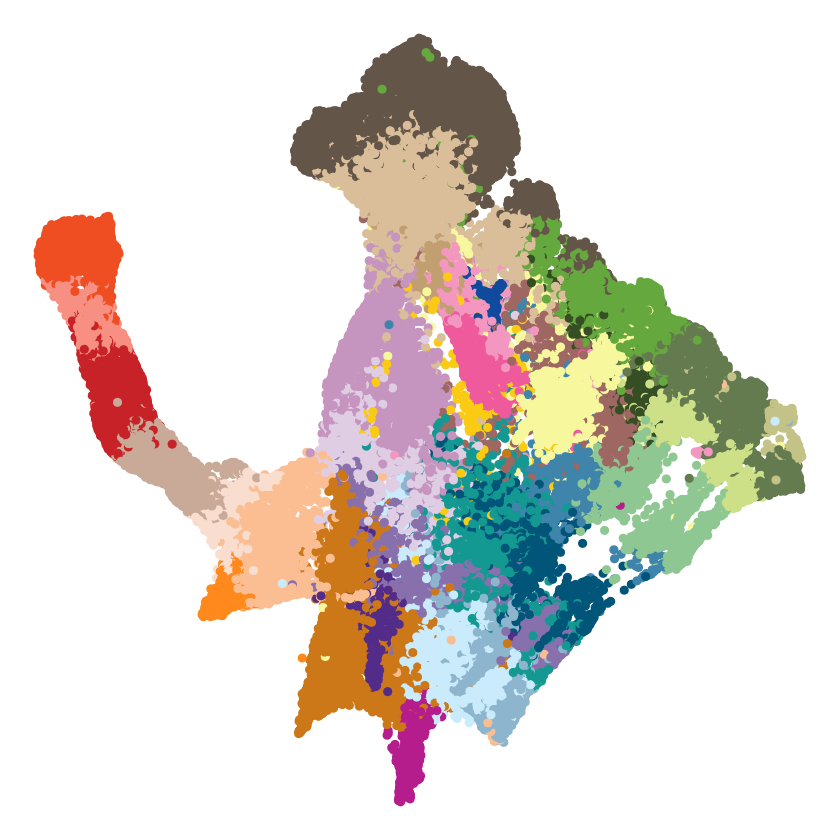

In [51]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=meta[match(colnames(seurat), cell),celltype])) + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void() + theme(legend.position='none')

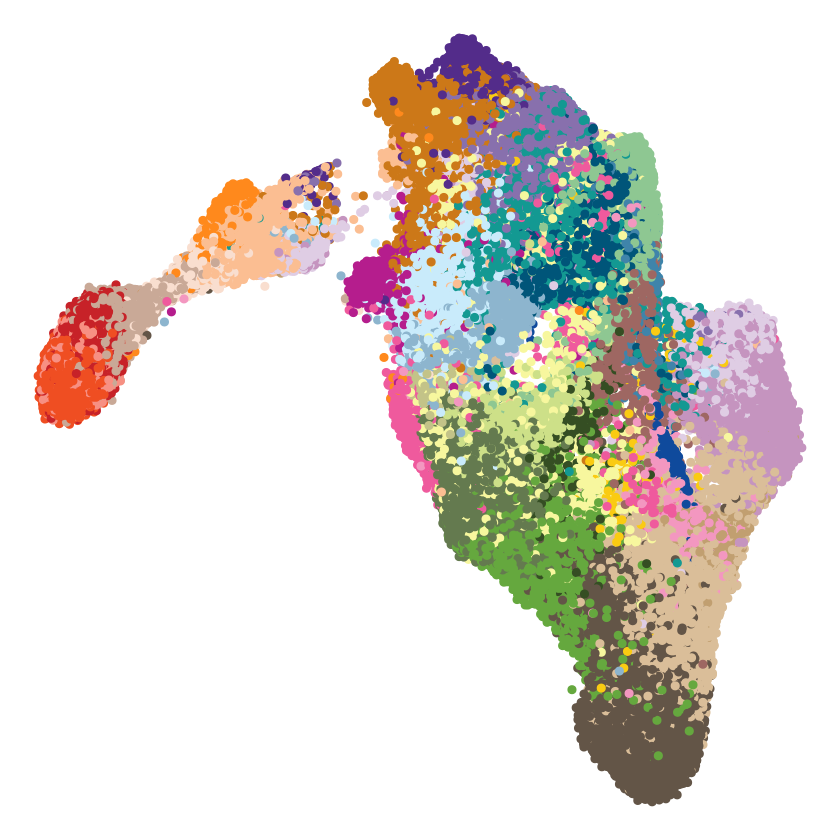

In [56]:
TFs = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/TFs.txt", header=F)
TFs_keep = intersect(stringr::str_to_title(TFs$V1), rownames(original_sce))
sce_TFs = original_sce[TFs_keep,]
sce_TFs <- runPCA(sce_TFs, ncomponents = 30, ntop=3000)
sce_TFs <- runUMAP(sce_TFs, dimred="PCA", n_neighbors = 30, min_dist = 0.3, BPPARAM = BPPARAM)
umap.dt <- reducedDim(sce_TFs,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_TFs)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

ggplot(umap.dt, aes(UMAP1, UMAP2, col=meta[match(colnames(seurat), cell),celltype])) + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void() + theme(legend.position='none')

In [58]:
# Get highly variable TFs
TFs = stringr::str_to_title(fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/TFs.txt", header=F)$V1)
TFs = intersect(stringr::str_to_title(TFs), rownames(original_sce))
decomp <- modelGeneVar(original_sce[TFs,])
decomp <- decomp[decomp$mean > 0.01,]
TFs_keep <- decomp[order(decomp$FDR),] %>% head(n=400) %>% rownames

genes = unique(c(TFs_keep, hvgs))
sce_filt_TFs <- original_sce[genes,]


In [59]:
logcounts = as.matrix(logcounts(sce_filt_TFs))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.2 GiB”


In [73]:
scaled_logcounts = t(scale(t(logcounts), center = TRUE, scale=TRUE))

In [74]:
# Save the matrix with row names as a CSV file
write.csv(scaled_logcounts, file = file.path(io$outdir, "scaled_logcounts.csv"), row.names = TRUE)

In [76]:
# Save the matrix with row names as a CSV file
write.csv(scaled_logcounts[, 1:20000], file = file.path(io$outdir, "scaled_logcounts_small.csv"), row.names = TRUE)

In [80]:
# Save the matrix with row names as a CSV file
write.csv(scaled_logcounts[, 1:50000], file = file.path(io$outdir, "scaled_logcounts_medium.csv"), row.names = TRUE)

In [60]:
## Get imputed data matrix, not working yet!
#get distance matrix
PCA = reducedDim(sce_filt,"PCA") 
NN = BiocNeighbors::findKNN(PCA, 10)

In [80]:
impute = function(x){
    tmp = as.matrix(rowMeans(logcounts[,NN[[1]][x,]]))
    colnames(tmp) = colnames(logcounts)[x]
    tmp = as.data.frame(tmp)
    return(tmp)
}


In [81]:
a = Sys.time()
logcounts_imputed = mclapply(sample(1:ncol(logcounts), 50000), impute, mc.cores=1) #%>% #ncol(logcounts)
   # do.call('cbind', .)
b = Sys.time()
b-a

Time difference of 25.12191 secs

In [82]:
logcounts_imputed_matrix = bind_cols(logcounts_imputed)

In [ ]:
rownames(logcounts_imputed_matrix) = rownames(logcounts)

In [117]:
# Save the matrix with row names as a CSV file
write.csv(round(logcounts_imputed_matrix, 4), file = file.path(io$outdir, "imputed_logcounts_medium.csv"), row.names = TRUE)

In [ ]:
umap.dt = umap.dt[cell %in% colnames(logcounts_imputed_matrix)] %>%
    .[match(colnames(logcounts_imputed_matrix), cell)]


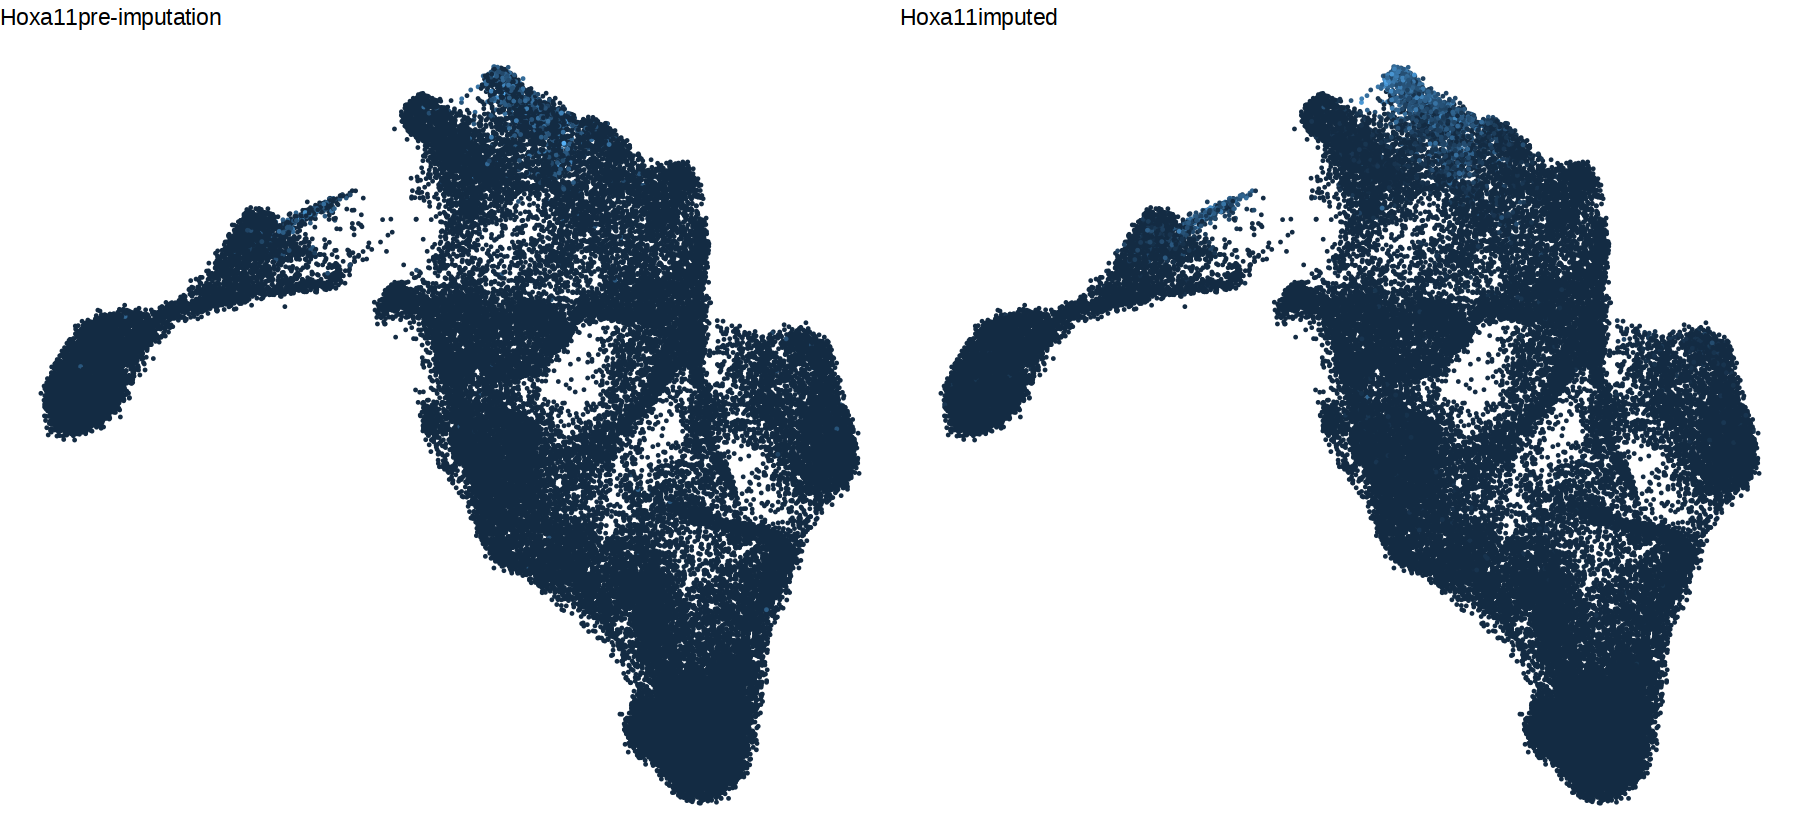

In [127]:
gene = 'Hoxa11'
p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.numeric(logcounts[gene, umap.dt$cell]))) + 
    geom_point(size=0.3) + 
    ggtitle(paste0(gene, 'pre-imputation')) + 
    theme_void() + theme(legend.position='none')

p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.numeric(logcounts_imputed_matrix[gene,]))) + 
    geom_point(size=0.3) + 
    ggtitle(paste0(gene, 'imputed')) + 
    theme_void() + theme(legend.position='none')
options(repr.plot.width=15)
ggarrange(p1, p2)

In [167]:
imputed_counts = fread(file.path(io$outdir, "predictions.csv"))[-1, -1] %>% 
    setnames(rownames(logcounts_imputed_matrix)[402:nrow(logcounts_imputed_matrix)]) %>% 
    as.data.frame() %>% t(.) 
    

In [168]:
colnames(imputed_counts) = colnames(logcounts_imputed_matrix)

In [ ]:
a

In [ ]:
head(imputed_counts)

In [169]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.numeric(imputed_counts[gene,]))) + 
    geom_point(size=0.3) + 
    ggtitle(paste0(gene, 'imputed')) + 
    theme_void() + theme(legend.position='none')

In [ ]:
a

In [3]:
imputed_counts = fread(file.path(io$outdir, "predictions.csv"))[-1, -1] %>% t()

In [4]:
sce <- SingleCellExperiment(list(logcounts=imputed_counts))

In [6]:
sce <- runPCA(sce, ncomponents = 30, ntop=3000)
sce <- runUMAP(sce, dimred="PCA", n_neighbors = 30, min_dist = 0.3)

Warning message in `[.data.table`(., , `:=`(cell, colnames(sce))):
“Column 'cell' does not exist to remove”


ERROR: Error in setnames(., c("UMAP1", "UMAP2", "cell")): Can't assign 3 names to a 2 column data.table


In [8]:
umap.dt <- reducedDim(sce,"UMAP") %>% as.data.table 

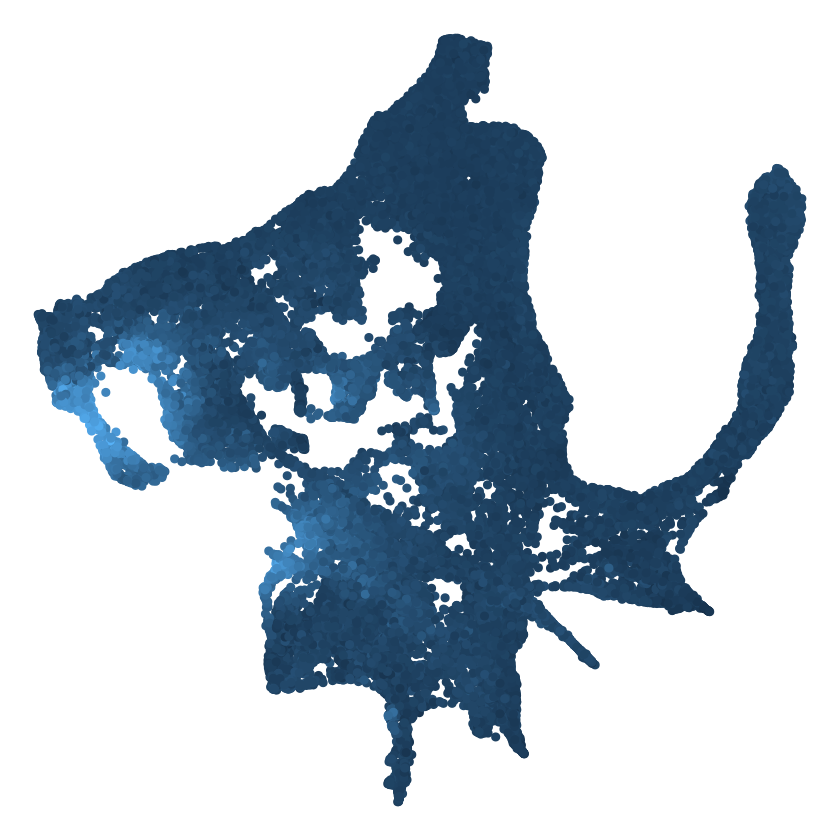

In [28]:
ggplot(umap.dt, aes(V1, V2, col=imputed_counts[1900,])) + 
    geom_point() + 
    theme_void() + theme(legend.position='none')